In [1]:
def H(z):
    return 1 if z >= 0 else 0

In [2]:
def output(x1, x2, w1, w2, b):
    z = w1*x1 + w2*x2 + b
    return H(z)

In [3]:
def p_learn(X, Y, w1, w2, b, eta):
    for epoch in range(10):
        for i in range(len(X)):
            x1, x2 = X[i]
            y_true = Y[i]

            y_pred = output(x1, x2, w1, w2, b)
            error = y_true - y_pred

            w1 += eta * error * x1
            w2 += eta * error * x2
            b  += eta * error

    return w1, w2, b

In [4]:
X = [[1,1], [1,0], [0,1], [0,0]]
Y = [1,1,1,0]

w1, w2, b = p_learn(X, Y, 0, 0, 0, 0.1)

for x in X:
    print(x, "->", output(x[0], x[1], w1, w2, b))

[1, 1] -> 1
[1, 0] -> 1
[0, 1] -> 1
[0, 0] -> 0


In [12]:
import numpy as np

def H(z):
    return np.where(z >= 0, 1, 0)

In [13]:
def output(x, w, b):
    z = np.dot(w, x) + b
    return H(z)

In [14]:
def p_learn(X, Y, w, b, eta, epochs):
    for _ in range(epochs):
        for i in range(len(X)):
            x = X[i]
            y_true = Y[i]

            y_pred = output(x, w, b)
            error = y_true - y_pred

            w = w + eta * error * x
            b = b + eta * error

    return w, b

In [15]:
X = np.array([[1,1], [1,0], [0,1], [0,0]])
Y = np.array([1,1,1,0])

w = np.zeros(2)
b = 0

w, b = p_learn(X, Y, w, b, eta=0.1, epochs=10)

print("Weights:", w)
print("Bias:", b)

Weights: [0.1 0.1]
Bias: -0.1


In [16]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, Y, w, b):
    # Create grid
    x_min, x_max = -1, 2
    y_min, y_max = -1, 2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Compute Z = w1*x + w2*y + b
    Z = w[0]*xx + w[1]*yy + b
    Z = H(Z)

    # Plot contour
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot data points
    for i in range(len(X)):
        if Y[i] == 1:
            plt.scatter(X[i][0], X[i][1])
        else:
            plt.scatter(X[i][0], X[i][1], marker='x')

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("Decision Boundary")
    plt.show()

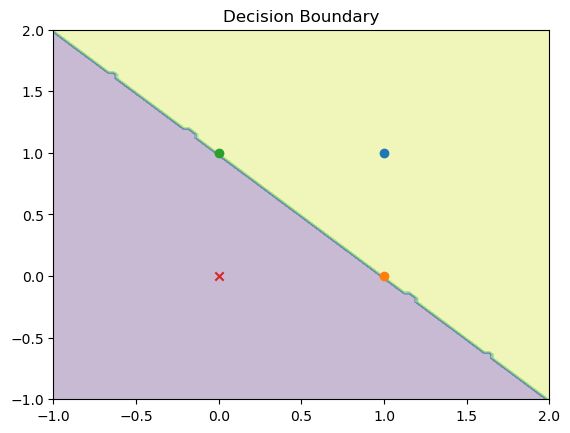

In [17]:
plot_decision_boundary(X, Y, w, b)

In [18]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs):
        self.n_inputs = n_inputs
        self.weights = np.zeros(n_inputs)
        self.bias = 0

    def H(self, z):
        return 1 if z >= 0 else 0

    def out(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.H(z)

    def learn(self, data_learn, eta, epochs):
        for _ in range(epochs):
            for x, y in data_learn:
                y_pred = self.out(x)
                error = y - y_pred

                self.weights += eta * error * x
                self.bias += eta * error

In [19]:
import matplotlib.pyplot as plt

def plot_boundary(model, X, Y):
    x_min, x_max = -1, 2
    y_min, y_max = -1, 2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = model.weights[0]*xx + model.weights[1]*yy + model.bias
    Z = np.where(Z >= 0, 1, 0)

    plt.contourf(xx, yy, Z, alpha=0.3)

    # plot points
    for i in range(len(X)):
        if Y[i] == 1:
            plt.scatter(X[i][0], X[i][1])
        else:
            plt.scatter(X[i][0], X[i][1], marker='x')

    plt.title("Decision Boundary")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

OR predictions:
[1 1] -> 1
[1 0] -> 1
[0 1] -> 1
[0 0] -> 0


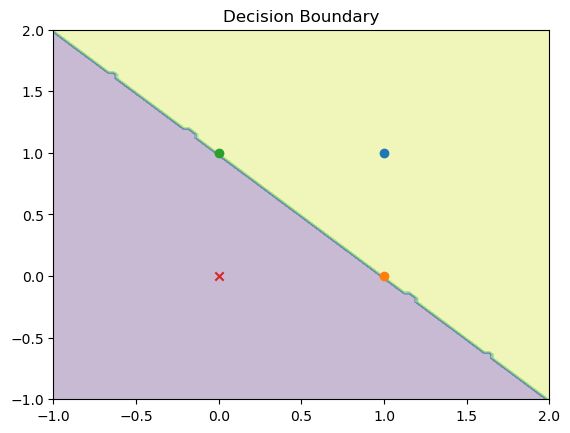

In [20]:
X = np.array([[1,1], [1,0], [0,1], [0,0]])
Y = np.array([1,1,1,0])

data = list(zip(X, Y))

p = Perceptron(2)
p.learn(data, eta=0.1, epochs=10)

print("OR predictions:")
for x in X:
    print(x, "->", p.out(x))

plot_boundary(p, X, Y)

AND predictions:
[1 1] -> 1
[1 0] -> 0
[0 1] -> 0
[0 0] -> 0


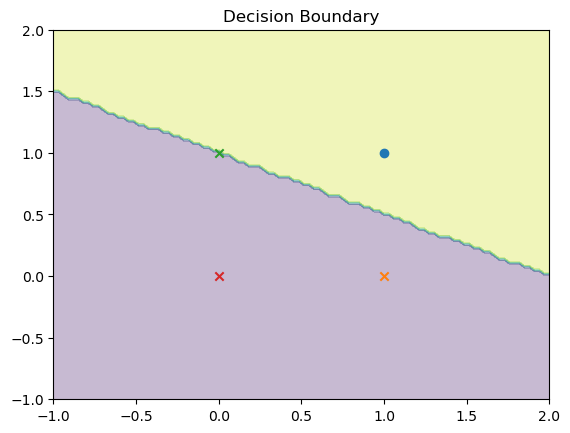

In [21]:
Y_and = np.array([1,0,0,0])

data = list(zip(X, Y_and))

p = Perceptron(2)
p.learn(data, eta=0.1, epochs=10)

print("AND predictions:")
for x in X:
    print(x, "->", p.out(x))

plot_boundary(p, X, Y_and)

NAND predictions:
[1 1] -> 0
[1 0] -> 1
[0 1] -> 1
[0 0] -> 1


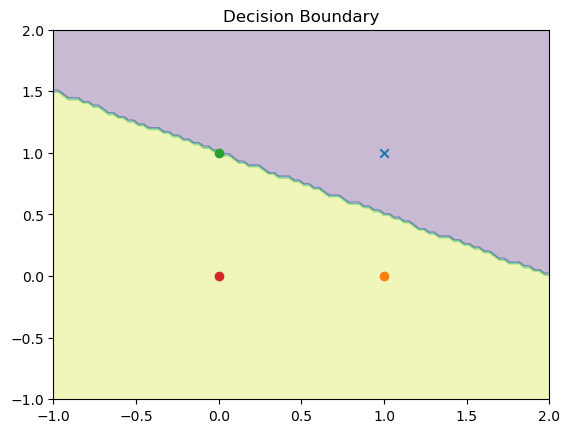

In [22]:
Y_nand = np.array([0,1,1,1])

data = list(zip(X, Y_nand))

p = Perceptron(2)
p.learn(data, eta=0.1, epochs=10)

print("NAND predictions:")
for x in X:
    print(x, "->", p.out(x))

plot_boundary(p, X, Y_nand)